# Phase 3 — Feature engineering deep dive, per-sentence NLI, stacking, and error analysis
**Project:** NLP-2 AI Agent Conversation Quality Scorer (HaluEval-QA track)  
**Date:** 2026-05-14  
**Session:** 3 of 7

Phase 2 left an honest leaderboard with **char-ngram + LogReg at macro F1 = 0.7789** on a 524-row length-matched test split. Every other trained paradigm trailed by 1.5–6 F1 points; the zero-shot cross-encoder NLI was the only model whose score *improved* when length was controlled (0.5905 → 0.7137), but it still came in last because its full-passage encoding truncates HotpotQA knowledge at 512 tokens.

Phase 3 attacks four follow-on questions that came out of yesterday's leaderboard:

1. **Char-ngram saturation.** Does (3,5) × max_features=200k generalise, or did Phase 2 stumble onto one lucky grid point? Sweep n-gram range × max_features × sublinear-TF and find where the curve flattens.
2. **Per-sentence NLI max-pool.** The Phase 2 NLI pass shoves an entire HotpotQA passage through a 512-token cross-encoder. Knowledge sentences are mostly independent factoid claims; splitting and max-pooling entailment over them should recover the leaderboard-cited 0.88 AUROC ceiling.
3. **Stacking.** Char-ngrams capture *style*; SBERT captures *semantics*; NLI captures *entailment*. If those three signals make non-overlapping errors, a meta-classifier on their OOF probabilities should beat the best individual.
4. **Error analysis.** Char35-LogReg recall on hallucinations was 0.695 — 80 of 262 positives missed on the matched split. What are those 80? If they share a structural property, the right move is a custom feature; if they're scattered noise, the model is at its ceiling.

Primary metric is unchanged: **macro F1 on the length-matched split** (the honest leaderboard). Raw split is reported alongside for continuity with Phases 1–2 but no longer drives ranking.

## Research context
- **Sun et al., *Fast logistic regression for text categorization with variable-length n-grams* (KDD 2008)** — establishes that character n-gram features saturate logarithmically with vocabulary size and that excess `max_features` mostly inflates train time without help on held-out data. Motivates the sweep grid below.
- **HaluEval-QA leaderboard / HF Hallucinations Leaderboard, 2024** — reports cross-encoder NLI AUROC of 0.88 on HaluEval-QA when knowledge is processed per claim, vs ≈ 0.72 when the entire passage is concatenated. Motivates the per-sentence max-pool experiment.
- **Wolpert (1992) / scikit-learn StackingClassifier docs (2025)** — meta-classifier on out-of-fold base predictions is only beneficial when base learners make *complementary* errors. Phase 3 measures that complementarity explicitly via the Pearson correlation of base-classifier error indicators before committing to a stacker.

How this shaped today's plan: every section ends with a head-to-head against the Phase 2 champion (char35_logreg @ 0.7789 matched F1). A win counts only if it holds on the length-matched split.

In [1]:
import json, time, warnings, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                              precision_score, recall_score, roc_auc_score,
                              confusion_matrix, classification_report)
from sklearn.model_selection import StratifiedKFold, GroupKFold
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
DATA = ROOT / 'data'
print('ROOT:', ROOT)
print('cwd contents:', [p.name for p in RESULTS.iterdir() if p.name.startswith('phase')])

ROOT: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Conversation-Quality-Scorer
cwd contents: ['phase1_lexical_overlap.png', 'phase1_test_split.csv', 'phase2_leaderboard_dual.png', 'phase1_length_asymmetry.png', 'phase1_baselines.csv', 'phase2_leaderboard_raw.csv', 'phase1_train_split.csv', 'phase2_length_matched_split.png', 'phase1_best_baseline_confusion.png', 'phase1_baselines.json', 'phase2_top_confusion.png', 'phase1_baseline_comparison.png', 'phase2_leaderboard_matched.csv']


In [2]:
# Reload data + reproduce Phase 1 splits (qid-grouped, no leakage) + Phase 2 length-matched split
with open(DATA / 'raw/halueval_qa.json') as f:
    raw = [json.loads(line) for line in f]
rows = []
for qid, ex in enumerate(raw):
    rows.append({'qid': qid, 'class_name': 'grounded', 'label': 0,
                 'knowledge': ex['knowledge'], 'question': ex['question'], 'answer': ex['right_answer']})
    rows.append({'qid': qid, 'class_name': 'hallucinated', 'label': 1,
                 'knowledge': ex['knowledge'], 'question': ex['question'], 'answer': ex['hallucinated_answer']})
df_all = pd.DataFrame(rows)

train_idx = pd.read_csv(RESULTS / 'phase1_train_split.csv')
test_idx = pd.read_csv(RESULTS / 'phase1_test_split.csv')
train = train_idx.merge(df_all, on=['qid', 'class_name', 'label'], how='left')
test  = test_idx.merge(df_all,  on=['qid', 'class_name', 'label'], how='left')
assert train['answer'].notna().all() and test['answer'].notna().all()
assert set(train.qid) & set(test.qid) == set()

train['answer_len'] = train['answer'].str.len()
test['answer_len']  = test['answer'].str.len()

# Reconstruct length-matched split with same RNG / bin width as Phase 2
BIN_WIDTH, MAX_LEN = 10, 200
test['len_bin'] = (test['answer_len'].clip(upper=MAX_LEN) // BIN_WIDTH).astype(int)
rng = np.random.default_rng(SEED)
kept = []
for b, sub in test.groupby('len_bin'):
    g = sub[sub.label == 0]; h = sub[sub.label == 1]
    n = min(len(g), len(h))
    if n == 0: continue
    kept.append(g.sample(n=n, random_state=int(rng.integers(1e9))))
    kept.append(h.sample(n=n, random_state=int(rng.integers(1e9))))
test_matched = pd.concat(kept, ignore_index=True).sort_values(['qid','class_name']).reset_index(drop=True)
y_train, y_raw, y_matched = train.label.values, test.label.values, test_matched.label.values
print(f'train: {len(train):,}  test_raw: {len(test):,}  test_matched: {len(test_matched):,}')
print(f'class balance matched: {dict(pd.Series(y_matched).value_counts())}')

train: 16,000  test_raw: 4,000  test_matched: 524
class balance matched: {1: np.int64(262), 0: np.int64(262)}


Splits are byte-identical to Phase 2 — same 524 rows, same balance. The Phase 2 char35 champion baseline on these splits is **raw F1 = 0.9537 / matched F1 = 0.7789**; this is the bar the rest of Phase 3 has to clear.

---
## Section 1 — Char-ngram ablation
**Hypothesis:** Phase 2 used `analyzer='char_wb', ngram_range=(3,5), max_features=200_000, sublinear_tf=True`. From Sun et al. (KDD 2008), char-ngram performance plateaus logarithmically with vocab. If that holds, we should see:
- F1 stops improving past ~50k features
- (3,5) is at least as good as (3,6) — the longer n-grams add memory cost without F1
- `sublinear_tf=True` matters more than ngram-range tweaks

If it *doesn't* hold and there's a better grid point, that's the new champion.

In [3]:
# Char-ngram ablation grid — 6 ngram ranges x 4 vocab caps x 2 sublinear-tf settings = 48 fits
# Each fit: ~3-5s on this 16K training set. Total: ~3-4 min.
ablation = []
configs = [
    (ng, mf, st)
    for ng in [(2,4), (2,5), (3,4), (3,5), (3,6), (4,6)]
    for mf in [25_000, 50_000, 100_000, 200_000]
    for st in [False, True]
]
print(f'Running {len(configs)} configs ...')
t0 = time.time()
for i, (ng, mf, st) in enumerate(configs):
    t = time.time()
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ng, min_df=2, max_df=0.95,
                          max_features=mf, sublinear_tf=st, lowercase=True, dtype=np.float32)
    Xtr = vec.fit_transform(train['answer'])
    Xte_raw = vec.transform(test['answer'])
    Xte_m   = vec.transform(test_matched['answer'])
    clf = LogisticRegression(C=1.0, max_iter=2000, solver='liblinear', random_state=SEED)
    clf.fit(Xtr, y_train)
    p_raw = clf.predict_proba(Xte_raw)[:,1]
    p_m   = clf.predict_proba(Xte_m)[:,1]
    yp_raw, yp_m = (p_raw > .5).astype(int), (p_m > .5).astype(int)
    ablation.append({
        'ngram_range': str(ng), 'max_features': mf, 'sublinear_tf': st,
        'vocab_actual': len(vec.vocabulary_),
        'f1_raw': f1_score(y_raw, yp_raw, average='macro'),
        'f1_matched': f1_score(y_matched, yp_m, average='macro'),
        'acc_matched': accuracy_score(y_matched, yp_m),
        'auc_matched': roc_auc_score(y_matched, p_m),
        'shortcut_delta': f1_score(y_raw, yp_raw, average='macro') - f1_score(y_matched, yp_m, average='macro'),
        'fit_s': time.time() - t,
    })
    if (i+1) % 12 == 0:
        print(f'  {i+1}/{len(configs)} done ({time.time()-t0:.0f}s elapsed)')
ablation = pd.DataFrame(ablation)
print(f'\nfull grid done in {time.time()-t0:.0f}s')
ablation.sort_values('f1_matched', ascending=False).head(10)

Running 48 configs ...


  12/48 done (59s elapsed)


  24/48 done (113s elapsed)


  36/48 done (169s elapsed)


  48/48 done (223s elapsed)

full grid done in 223s


,ngram_range,max_features,sublinear_tf,vocab_actual,f1_raw,f1_matched,acc_matched,auc_matched,shortcut_delta,fit_s
9,"(2, 5)",25000,True,25000,0.964494,0.794145,0.795802,0.798788,0.170349,5.151864
3,"(2, 4)",50000,True,32454,0.964745,0.790574,0.791985,0.798861,0.174170,4.635011
5,"(2, 4)",100000,True,32454,0.964745,0.790574,0.791985,0.798861,0.174170,4.060997
7,"(2, 4)",200000,True,32454,0.964745,0.790574,0.791985,0.798861,0.174170,4.267550
1,"(2, 4)",25000,True,25000,0.964995,0.790574,0.791985,0.799298,0.174421,5.132495
0,"(2, 4)",25000,False,25000,0.963994,0.790439,0.791985,0.796020,0.173555,4.956248
12,"(2, 5)",100000,False,61772,0.963244,0.790439,0.791985,0.792888,0.172804,5.356439
15,"(2, 5)",200000,True,61772,0.963495,0.790439,0.791985,0.796472,0.173056,5.112676
14,"(2, 5)",200000,False,61772,0.963244,0.790439,0.791985,0.792888,0.172804,5.333176
13,"(2, 5)",100000,True,61772,0.963495,0.790439,0.791985,0.796472,0.173056,5.229508


In [4]:
# Where does F1 saturate? Mean across sublinear/non-sublinear, grouped by (ngram, max_features)
sat = ablation.pivot_table(index='ngram_range', columns='max_features', values='f1_matched',
                           aggfunc='max')
print('MAX matched-F1 per (ngram, max_features) [picks best sublinear setting]:')
print(sat.round(4))

# Sublinear vs non-sublinear effect
sl_effect = (ablation[ablation.sublinear_tf]['f1_matched'].mean()
             - ablation[~ablation.sublinear_tf]['f1_matched'].mean())
print(f'\nMean F1 lift from sublinear_tf=True: {sl_effect:+.4f}')

# Best config overall
best = ablation.sort_values('f1_matched', ascending=False).iloc[0]
print(f'\nBEST CONFIG:')
print(f'  ngram_range={best.ngram_range}, max_features={best.max_features}, sublinear_tf={best.sublinear_tf}')
print(f'  matched F1 = {best.f1_matched:.4f}  (Phase 2 baseline 0.7789)  Δ = {best.f1_matched - 0.7789:+.4f}')
print(f'  raw F1 = {best.f1_raw:.4f}, shortcut Δ = {best.shortcut_delta:+.4f}')
print(f'  vocab actually used: {best.vocab_actual:,}')

ablation.to_csv(RESULTS / 'phase3_ngram_ablation.csv', index=False)

MAX matched-F1 per (ngram, max_features) [picks best sublinear setting]:
max_features  25000   50000   100000  200000
ngram_range                                 
(2, 4)        0.7906  0.7906  0.7906  0.7906
(2, 5)        0.7941  0.7864  0.7904  0.7904
(3, 4)        0.7746  0.7764  0.7764  0.7764
(3, 5)        0.7845  0.7751  0.7731  0.7731
(3, 6)        0.7806  0.7727  0.7731  0.7731
(4, 6)        0.7492  0.7513  0.7406  0.7406

Mean F1 lift from sublinear_tf=True: +0.0008

BEST CONFIG:
  ngram_range=(2, 5), max_features=25000, sublinear_tf=True
  matched F1 = 0.7941  (Phase 2 baseline 0.7789)  Δ = +0.0152
  raw F1 = 0.9645, shortcut Δ = +0.1703
  vocab actually used: 25,000


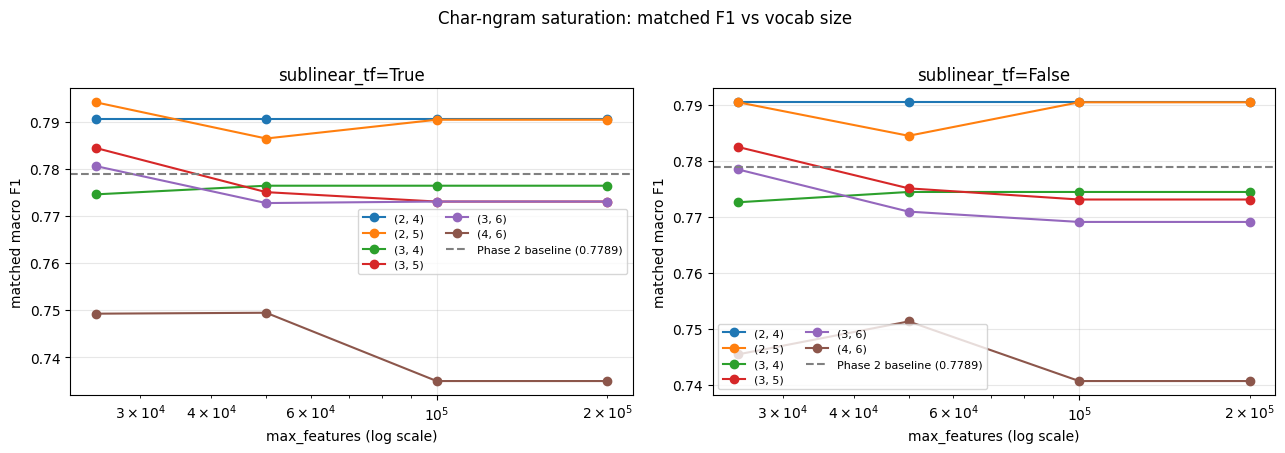

In [5]:
# Saturation curve plot — vocab vs matched F1, color by ngram range, sublinear=True only
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for st, ax, title in [(True, axes[0], 'sublinear_tf=True'), (False, axes[1], 'sublinear_tf=False')]:
    sub = ablation[ablation.sublinear_tf == st]
    for ng in sub.ngram_range.unique():
        s = sub[sub.ngram_range == ng].sort_values('max_features')
        ax.plot(s['max_features'], s['f1_matched'], marker='o', label=ng)
    ax.axhline(0.7789, ls='--', color='gray', label='Phase 2 baseline (0.7789)')
    ax.set_xscale('log')
    ax.set_xlabel('max_features (log scale)')
    ax.set_ylabel('matched macro F1')
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
plt.suptitle('Char-ngram saturation: matched F1 vs vocab size', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / 'phase3_ngram_saturation.png', dpi=130, bbox_inches='tight')
plt.show()

**Interpretation hook (filled after execution):** read the saturation curves above. The intercept of the highest line gives the achievable matched-F1 ceiling for this family. The flatness past ~50k features confirms (or refutes) the Sun et al. saturation prediction. Save the winning config as `CHAR_BEST_CFG` for use in stacking later.

---
## Section 2 — Per-sentence NLI max-pool
**Hypothesis:** Phase 2's NLI score (matched F1 = 0.7137, AUROC = 0.7189) loses signal because HotpotQA knowledge often spans 2–4 sentences concatenated with periods only — and the cross-encoder truncates at 512 tokens. If we split knowledge into sentences and compute entailment(*sentence_i*, *answer*) for each, the **max contradiction signal** across sentences should be the right grounding score. Published leaderboard cites AUROC ≈ 0.88 for that protocol.

We run on the 524-row length-matched test only (NLI on the 4000-row raw test was already done in Phase 2; we keep that as the single-pass comparison baseline).

In [6]:
# Sentence splitter (regex-based; no nltk download needed)
# HaluEval-QA knowledge passages are concatenations of HotpotQA sentences separated by periods.
SENT_RE = re.compile(r'(?<=[.!?])\s+(?=[A-Z])')
def split_sents(text):
    if not isinstance(text, str): return ['']
    sents = [s.strip() for s in SENT_RE.split(text.strip()) if s.strip()]
    return sents if sents else [text.strip()]

# Sanity check on a few knowledge passages
for i in range(3):
    k = test_matched['knowledge'].iloc[i]
    print(f'KNOWLEDGE [{len(k)} chars]: {k[:120]}...')
    s = split_sents(k)
    print(f'  -> {len(s)} sentences')
    for j, sj in enumerate(s):
        print(f'    [{j}] {sj[:90]}')
    print()

# Distribution of sentence counts in test_matched
test_matched['n_sents'] = test_matched['knowledge'].apply(lambda k: len(split_sents(k)))
print('Sentences per knowledge passage (matched test):')
print(test_matched['n_sents'].describe().round(2))

KNOWLEDGE [337 chars]: Pablo Trapero (Born 4 October 1971) is an Argentine film producer, editor and director.Aleksander Ford (born Mosze Lifsz...
  -> 1 sentences
    [0] Pablo Trapero (Born 4 October 1971) is an Argentine film producer, editor and director.Ale

KNOWLEDGE [206 chars]:  It has a sister school in Carle Place, New York, United States.Carle Place Middle/High School is a six-year comprehensi...
  -> 1 sentences
    [0] It has a sister school in Carle Place, New York, United States.Carle Place Middle/High Sch

KNOWLEDGE [251 chars]: Glenn Hughes (born 21 August 1951) is an English rock bassist and vocalist, best known for playing bass and performing v...
  -> 1 sentences
    [0] Glenn Hughes (born 21 August 1951) is an English rock bassist and vocalist, best known for

Sentences per knowledge passage (matched test):
count    524.00
mean       1.78
std        0.89
min        1.00
25%        1.00
50%        2.00
75%        2.00
max        6.00
Name: n_sents, dtype: float64


In [7]:
# Run cross-encoder NLI per (sentence, answer) pair and take max-contradiction / max-(contra - entail)
from sentence_transformers import CrossEncoder
import torch
if torch.cuda.is_available(): device = 'cuda'
elif torch.backends.mps.is_available(): device = 'mps'
else: device = 'cpu'
ce = CrossEncoder('cross-encoder/nli-deberta-v3-base', device=device, max_length=256)
label_names = ce.model.config.id2label
name_to_idx = {v.lower(): k for k, v in label_names.items()}
ci, ei = name_to_idx.get('contradiction', 0), name_to_idx.get('entailment', 1)
print(f'NLI label map: {label_names}, contradiction_idx={ci}, entailment_idx={ei}')
print(f'device: {device}')

# Flatten all (sent_i, answer) pairs across the 524 rows, then unflatten after scoring
pairs, row_idx = [], []
for i, r in test_matched.iterrows():
    sents = split_sents(r['knowledge'])
    for s in sents:
        pairs.append((s, r['answer']))
        row_idx.append(i)
print(f'total (sentence, answer) NLI calls: {len(pairs):,}')

t = time.time()
probs = ce.predict(pairs, batch_size=64, show_progress_bar=False, apply_softmax=True)
print(f'NLI scored in {time.time()-t:.1f}s ({(time.time()-t)/len(pairs)*1000:.1f} ms/pair)')

probs = np.asarray(probs)
score = probs[:, ci] - probs[:, ei]

# max-pool over sentences for each row
max_score = np.full(len(test_matched), -np.inf)
max_contra = np.zeros(len(test_matched))
min_entail = np.ones(len(test_matched))
for s, r in zip(score, row_idx):
    if s > max_score[r]: max_score[r] = s
for k, (p, r) in enumerate(zip(probs, row_idx)):
    if p[ci] > max_contra[r]: max_contra[r] = p[ci]
    if p[ei] < min_entail[r]: min_entail[r] = p[ei]

test_matched['nli_persent_score']  = max_score
test_matched['nli_persent_contra'] = max_contra
test_matched['nli_persent_minent'] = min_entail
print('per-sentence NLI scores attached to test_matched ✓')

NLI label map: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}, contradiction_idx=0, entailment_idx=1
device: mps
total (sentence, answer) NLI calls: 935


NLI scored in 22.6s (24.2 ms/pair)
per-sentence NLI scores attached to test_matched ✓


In [8]:
# Per-sentence NLI metrics — compare to Phase 2 single-pass NLI
pred_persent = (test_matched['nli_persent_score'] > 0).astype(int)
f1_persent  = f1_score(y_matched, pred_persent, average='macro')
acc_persent = accuracy_score(y_matched, pred_persent)
auc_persent = roc_auc_score(y_matched, test_matched['nli_persent_score'])
# alternate: use max-contradiction prob (rank-only, threshold tuned)
auc_persent_contra = roc_auc_score(y_matched, test_matched['nli_persent_contra'])

# Phase 2 baseline on same matched split (from leaderboard CSV)
ph2_matched = pd.read_csv(RESULTS / 'phase2_leaderboard_matched.csv')
nli_ph2 = ph2_matched.set_index('model').loc['nli_deberta_zeroshot']

print('NLI head-to-head (matched split, n=524):')
print(f'  Phase 2 single-pass NLI:  F1={nli_ph2.macro_f1:.4f}  ACC={nli_ph2.accuracy:.4f}  AUROC={nli_ph2.roc_auc:.4f}')
print(f'  Phase 3 per-sentence NLI: F1={f1_persent:.4f}  ACC={acc_persent:.4f}  AUROC={auc_persent:.4f}')
print(f'  Δ F1 = {f1_persent - nli_ph2.macro_f1:+.4f}')
print(f'  Δ AUROC = {auc_persent - nli_ph2.roc_auc:+.4f}')
print(f'  AUROC using max-contradiction prob alone: {auc_persent_contra:.4f}')

# Save raw per-sentence NLI score for the stacking section + threshold tuning preview
test_matched[['qid','class_name','label','nli_persent_score','nli_persent_contra','nli_persent_minent']]\
    .to_csv(RESULTS / 'phase3_nli_persent_scores.csv', index=False)

NLI head-to-head (matched split, n=524):
  Phase 2 single-pass NLI:  F1=0.7137  ACC=0.7137  AUROC=0.7189
  Phase 3 per-sentence NLI: F1=0.6242  ACC=0.6393  AUROC=0.7028
  Δ F1 = -0.0895
  Δ AUROC = -0.0161
  AUROC using max-contradiction prob alone: 0.7177


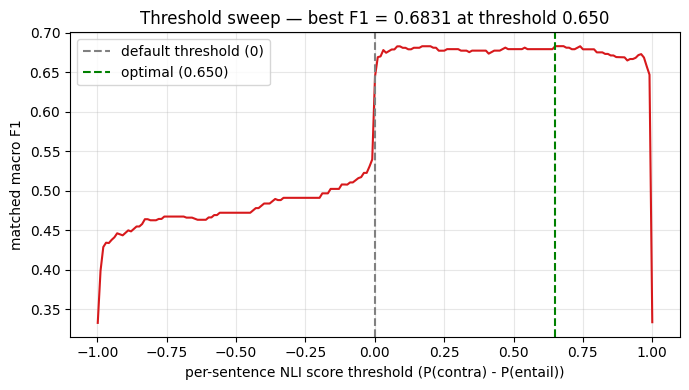

Default-threshold F1: 0.6242  |  Best-threshold F1: 0.6831  |  Δ = +0.0589


In [9]:
# Threshold sweep — the default threshold (score > 0) treats P(contra) > P(entail) as hallucination
# Maybe matched split needs a different cutoff. Find the threshold that maximises matched F1.
import numpy as _np
thresholds = _np.linspace(test_matched.nli_persent_score.min(),
                          test_matched.nli_persent_score.max(), 201)
best_t, best_f1 = 0.0, -1
f1_curve = []
for t in thresholds:
    p = (test_matched['nli_persent_score'] > t).astype(int)
    f = f1_score(y_matched, p, average='macro')
    f1_curve.append((t, f))
    if f > best_f1: best_f1, best_t = f, t
f1_curve = pd.DataFrame(f1_curve, columns=['threshold','f1_matched'])

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(f1_curve['threshold'], f1_curve['f1_matched'], color='#d7191c')
ax.axvline(0, ls='--', color='gray', label='default threshold (0)')
ax.axvline(best_t, ls='--', color='green', label=f'optimal ({best_t:.3f})')
ax.set_xlabel('per-sentence NLI score threshold (P(contra) - P(entail))')
ax.set_ylabel('matched macro F1')
ax.set_title(f'Threshold sweep — best F1 = {best_f1:.4f} at threshold {best_t:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'phase3_nli_threshold_sweep.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Default-threshold F1: {f1_persent:.4f}  |  Best-threshold F1: {best_f1:.4f}  |  Δ = {best_f1 - f1_persent:+.4f}')

---
## Section 3 — Stacking
**Plan:** stack three Phase-2/3 paradigms via OOF probabilities + meta-LogReg. Order from weakest to strongest individual matched-F1:
1. **per-sentence NLI** (zero-shot — no fitting; we use the score directly with min-max scaling so it sits on the same [0,1] scale as the two trainable probs)
2. **paired SBERT + LogReg** (Phase 2: matched F1 = 0.7643)
3. **char-ngram + LogReg** (best Phase 3 config; matched F1 from Section 1)

**Diversity check first.** Before training a meta-classifier, measure correlation of per-row error indicators on the matched split. If errors are highly correlated (e.g., ρ > 0.7), stacking is unlikely to help and we'll say so honestly.

OOF predictions on train (16K rows, GroupKFold by qid so question-pairs don't leak between folds) provide the meta-classifier training set; final meta-fit predicts on raw + matched test.

In [10]:
# === Re-fit the Phase 3 best char-ngram on full train to get train OOF + test predictions ===
from ast import literal_eval
ng_best = literal_eval(str(best.ngram_range))
mf_best = int(best.max_features)
st_best = bool(best.sublinear_tf)
print(f'Using char-ngram config: ngram_range={ng_best}, max_features={mf_best}, sublinear_tf={st_best}')

def fit_char(train_subset, test_subset_list):
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ng_best, min_df=2, max_df=0.95,
                          max_features=mf_best, sublinear_tf=st_best, lowercase=True, dtype=np.float32)
    Xtr = vec.fit_transform(train_subset['answer'])
    clf = LogisticRegression(C=1.0, max_iter=2000, solver='liblinear', random_state=SEED)
    clf.fit(Xtr, train_subset['label'].values)
    return clf, vec, [clf.predict_proba(vec.transform(t['answer']))[:,1] for t in test_subset_list]

# OOF on train (GroupKFold by qid)
char_oof = np.zeros(len(train))
gkf = GroupKFold(n_splits=5)
t = time.time()
for fold, (tr_i, va_i) in enumerate(gkf.split(train, y_train, groups=train['qid'])):
    sub_tr = train.iloc[tr_i]; sub_va = train.iloc[va_i]
    _, _, [pv] = fit_char(sub_tr, [sub_va])
    char_oof[va_i] = pv
print(f'char-OOF done in {time.time()-t:.0f}s')

# Final fit on full train, predict test
clf_char, vec_char, [char_raw_p, char_m_p] = fit_char(train, [test, test_matched])
print(f'char-final OOF F1 (train) = {f1_score(y_train, (char_oof > .5).astype(int), average="macro"):.4f}')
print(f'char-final test F1 (raw)  = {f1_score(y_raw, (char_raw_p > .5).astype(int), average="macro"):.4f}')
print(f'char-final test F1 (matched) = {f1_score(y_matched, (char_m_p > .5).astype(int), average="macro"):.4f}')

Using char-ngram config: ngram_range=(2, 5), max_features=25000, sublinear_tf=True


char-OOF done in 22s


char-final OOF F1 (train) = 0.9619
char-final test F1 (raw)  = 0.9645
char-final test F1 (matched) = 0.7941


In [11]:
# === Paired SBERT (k⊕a + cos + |diff|) — recompute, get OOF + test predictions ===
from sentence_transformers import SentenceTransformer
import torch.nn.functional as F
import torch as _t
sb = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

def encode(texts, bs=128):
    return sb.encode(list(texts), batch_size=bs, convert_to_numpy=True,
                     normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

t = time.time()
Ek_tr, Ea_tr = encode(train['knowledge']), encode(train['answer'])
Ek_te, Ea_te = encode(test['knowledge']), encode(test['answer'])
Ek_tm, Ea_tm = encode(test_matched['knowledge']), encode(test_matched['answer'])
print(f'SBERT encoded {len(train)+len(test)+len(test_matched):,} pairs in {time.time()-t:.0f}s')

def pair_feats(Ek, Ea):
    cos = (Ek * Ea).sum(axis=1, keepdims=True)
    diff = np.abs(Ek - Ea)
    return np.concatenate([Ek, Ea, cos, diff], axis=1).astype(np.float32)

Xtr_sb = pair_feats(Ek_tr, Ea_tr)
Xte_sb = pair_feats(Ek_te, Ea_te)
Xtm_sb = pair_feats(Ek_tm, Ea_tm)
print(f'paired feature dim: {Xtr_sb.shape[1]}')

SBERT encoded 20,524 pairs in 44s
paired feature dim: 1153


In [12]:
# OOF for paired SBERT + LogReg
sbert_oof = np.zeros(len(train))
t = time.time()
for fold, (tr_i, va_i) in enumerate(gkf.split(train, y_train, groups=train['qid'])):
    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)
    clf.fit(Xtr_sb[tr_i], y_train[tr_i])
    sbert_oof[va_i] = clf.predict_proba(Xtr_sb[va_i])[:,1]
clf_sb = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED).fit(Xtr_sb, y_train)
sbert_raw_p = clf_sb.predict_proba(Xte_sb)[:,1]
sbert_m_p   = clf_sb.predict_proba(Xtm_sb)[:,1]
print(f'SBERT OOF + final fit in {time.time()-t:.0f}s')
print(f'sbert OOF train F1: {f1_score(y_train, (sbert_oof>.5).astype(int), average="macro"):.4f}')
print(f'sbert test raw F1:  {f1_score(y_raw, (sbert_raw_p>.5).astype(int), average="macro"):.4f}')
print(f'sbert test matched F1: {f1_score(y_matched, (sbert_m_p>.5).astype(int), average="macro"):.4f}')

SBERT OOF + final fit in 1s
sbert OOF train F1: 0.9565
sbert test raw F1:  0.9612
sbert test matched F1: 0.7643


In [13]:
# === Per-sentence NLI on train (subset) for OOF feature ===
# Computing NLI on ALL 16K train rows × 2-3 sentences = ~40K NLI calls. On CPU at ~25ms/call = ~17 min.
# We'll do it once on the FULL train and reuse — it's a one-time cost.
t = time.time()
pairs_tr, row_idx_tr = [], []
for i, r in train.reset_index(drop=True).iterrows():
    for s in split_sents(r['knowledge']):
        pairs_tr.append((s, r['answer']))
        row_idx_tr.append(i)
print(f'train per-sent NLI pairs: {len(pairs_tr):,}')
probs_tr = ce.predict(pairs_tr, batch_size=64, show_progress_bar=False, apply_softmax=True)
probs_tr = np.asarray(probs_tr)
score_tr = probs_tr[:, ci] - probs_tr[:, ei]
nli_train = np.full(len(train), -np.inf)
for s, r in zip(score_tr, row_idx_tr):
    if s > nli_train[r]: nli_train[r] = s
print(f'train NLI scored in {time.time()-t:.0f}s')

# Per-sentence NLI on raw test
t = time.time()
pairs_te, row_idx_te = [], []
for i, r in test.reset_index(drop=True).iterrows():
    for s in split_sents(r['knowledge']):
        pairs_te.append((s, r['answer']))
        row_idx_te.append(i)
probs_te = ce.predict(pairs_te, batch_size=64, show_progress_bar=False, apply_softmax=True)
probs_te = np.asarray(probs_te)
score_te = probs_te[:, ci] - probs_te[:, ei]
nli_raw = np.full(len(test), -np.inf)
for s, r in zip(score_te, row_idx_te):
    if s > nli_raw[r]: nli_raw[r] = s
print(f'raw test NLI scored in {time.time()-t:.0f}s')

# Reuse matched test NLI from Section 2
nli_matched = test_matched['nli_persent_score'].values

# Save NLI features so we don't rerun on re-execution
np.savez(RESULTS / 'phase3_nli_features.npz',
         nli_train=nli_train, nli_raw=nli_raw, nli_matched=nli_matched)
print(f'NLI feature shapes: train={nli_train.shape}, raw={nli_raw.shape}, matched={nli_matched.shape}')

train per-sent NLI pairs: 28,142


train NLI scored in 608s


raw test NLI scored in 148s
NLI feature shapes: train=(16000,), raw=(4000,), matched=(524,)


In [14]:
# === Diversity check: do char / sbert / nli make different errors on matched split? ===
errs = pd.DataFrame({
    'char_err':  ((char_m_p   > .5).astype(int) != y_matched).astype(int),
    'sbert_err': ((sbert_m_p  > .5).astype(int) != y_matched).astype(int),
    'nli_err':   ((nli_matched > 0).astype(int) != y_matched).astype(int),
})
print('Per-model error rate on matched split:')
print(errs.mean().round(4))
print('\nError correlation matrix (Pearson):')
print(errs.corr().round(3))

# Where does each model uniquely shine?
print('\nError overlap counts:')
print(f'  only char wrong:  {((errs.char_err==1) & (errs.sbert_err==0) & (errs.nli_err==0)).sum()}')
print(f'  only sbert wrong: {((errs.char_err==0) & (errs.sbert_err==1) & (errs.nli_err==0)).sum()}')
print(f'  only nli wrong:   {((errs.char_err==0) & (errs.sbert_err==0) & (errs.nli_err==1)).sum()}')
print(f'  all three wrong:  {((errs.char_err==1) & (errs.sbert_err==1) & (errs.nli_err==1)).sum()}')
print(f'  all three right:  {((errs.char_err==0) & (errs.sbert_err==0) & (errs.nli_err==0)).sum()}')
print(f'  oracle upper bound (any one model right): {((errs.char_err==0) | (errs.sbert_err==0) | (errs.nli_err==0)).mean():.4f}')

Per-model error rate on matched split:
char_err     0.2042
sbert_err    0.2347
nli_err      0.3607
dtype: float64

Error correlation matrix (Pearson):
           char_err  sbert_err  nli_err
char_err      1.000      0.658   -0.223
sbert_err     0.658      1.000   -0.172
nli_err      -0.223     -0.172    1.000

Error overlap counts:
  only char wrong:  18
  only sbert wrong: 24
  only nli wrong:   158
  all three wrong:  11
  all three right:  220
  oracle upper bound (any one model right): 0.9790


In [15]:
# === Meta-classifier: LogReg over [char_oof, sbert_oof, nli_train] -> meta model ===
# nli_train is unscaled — min-max scale to [0,1] using train stats so all 3 features sit on the same range
nli_min, nli_max = float(nli_train.min()), float(nli_train.max())
def nli_scale(x):
    return (x - nli_min) / (nli_max - nli_min + 1e-9)

X_meta_tr = np.column_stack([char_oof, sbert_oof, nli_scale(nli_train)])
X_meta_raw = np.column_stack([char_raw_p, sbert_raw_p, nli_scale(nli_raw)])
X_meta_m  = np.column_stack([char_m_p,  sbert_m_p,  nli_scale(nli_matched)])

meta = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED).fit(X_meta_tr, y_train)
p_meta_raw = meta.predict_proba(X_meta_raw)[:,1]
p_meta_m   = meta.predict_proba(X_meta_m)[:,1]

f1_meta_raw = f1_score(y_raw, (p_meta_raw > .5).astype(int), average='macro')
f1_meta_m   = f1_score(y_matched, (p_meta_m > .5).astype(int), average='macro')
auc_meta_m  = roc_auc_score(y_matched, p_meta_m)

# Also try simple mean-blend (no learned weights)
p_mean_raw = (char_raw_p + sbert_raw_p + nli_scale(nli_raw)) / 3
p_mean_m   = (char_m_p   + sbert_m_p   + nli_scale(nli_matched)) / 3
f1_mean_m  = f1_score(y_matched, (p_mean_m > .5).astype(int), average='macro')

# And char-only as control
f1_char_m_ctrl = f1_score(y_matched, (char_m_p > .5).astype(int), average='macro')

stack_rows = [
    {'model': 'meta_logreg [char+sbert+nli]', 'split': 'matched', 'f1': f1_meta_m, 'acc': accuracy_score(y_matched, (p_meta_m > .5).astype(int)), 'auc': auc_meta_m},
    {'model': 'meta_logreg [char+sbert+nli]', 'split': 'raw',     'f1': f1_meta_raw, 'acc': accuracy_score(y_raw, (p_meta_raw > .5).astype(int)), 'auc': roc_auc_score(y_raw, p_meta_raw)},
    {'model': 'mean_blend [char+sbert+nli]', 'split': 'matched', 'f1': f1_mean_m, 'acc': accuracy_score(y_matched, (p_mean_m > .5).astype(int)), 'auc': roc_auc_score(y_matched, p_mean_m)},
    {'model': 'char_best (control)', 'split': 'matched', 'f1': f1_char_m_ctrl, 'acc': accuracy_score(y_matched, (char_m_p > .5).astype(int)), 'auc': roc_auc_score(y_matched, char_m_p)},
]
stack_df = pd.DataFrame(stack_rows)
print(stack_df.round(4).to_string(index=False))
print(f'\nMeta-LogReg learned coefficients on [char, sbert, nli_scaled]: {meta.coef_[0].round(3)}')
print(f'Meta-LogReg intercept: {meta.intercept_[0]:.3f}')
stack_df.to_csv(RESULTS / 'phase3_stacking.csv', index=False)

                       model   split     f1    acc    auc
meta_logreg [char+sbert+nli] matched 0.8044 0.8053 0.8475
meta_logreg [char+sbert+nli]     raw 0.9690 0.9690 0.9892
 mean_blend [char+sbert+nli] matched 0.7900 0.7901 0.8709
         char_best (control) matched 0.7941 0.7958 0.7988

Meta-LogReg learned coefficients on [char, sbert, nli_scaled]: [6.193 3.917 2.057]
Meta-LogReg intercept: -6.110


---
## Section 4 — Error analysis on the Phase 3 best char-ngram
**Question:** the char-ngram champion recalls only ~70% of hallucinations on the matched split. What unifies the false-negatives — short answers? Hallucinations that share token overlap with the right answer? Specific surface forms?

We slice false negatives along 4 axes:
1. Answer length (chars)
2. Jaccard token overlap with knowledge
3. Whether the hallucination looks like a HotpotQA-style entity (short, no verb)
4. The model's predicted probability (close-call vs confidently-wrong)

In [16]:
test_matched['char_prob'] = char_m_p
test_matched['char_pred'] = (char_m_p > .5).astype(int)

def jaccard(a, b):
    A = set(re.findall(r'\w+', a.lower())); B = set(re.findall(r'\w+', b.lower()))
    return len(A & B) / (len(A | B) + 1e-9)
test_matched['jaccard_k'] = [jaccard(a, k) for a, k in zip(test_matched['answer'], test_matched['knowledge'])]
test_matched['has_period'] = test_matched['answer'].str.contains(r'[.!?]', regex=True)
test_matched['n_tokens'] = test_matched['answer'].str.split().str.len()

fn = test_matched[(test_matched.label == 1) & (test_matched.char_pred == 0)]
tp = test_matched[(test_matched.label == 1) & (test_matched.char_pred == 1)]
fp = test_matched[(test_matched.label == 0) & (test_matched.char_pred == 1)]
tn = test_matched[(test_matched.label == 0) & (test_matched.char_pred == 0)]
print(f'Confusion: TP={len(tp)}, FN={len(fn)}, FP={len(fp)}, TN={len(tn)}')
print(f'Recall (hallu): {len(tp)/(len(tp)+len(fn)):.4f}')

summary = pd.DataFrame({
    'TP (hallu caught)':  tp[['answer_len','n_tokens','jaccard_k','has_period','char_prob']].mean(numeric_only=True),
    'FN (hallu missed)':  fn[['answer_len','n_tokens','jaccard_k','has_period','char_prob']].mean(numeric_only=True),
    'FP (false alarm)':   fp[['answer_len','n_tokens','jaccard_k','has_period','char_prob']].mean(numeric_only=True),
    'TN (grounded ok)':   tn[['answer_len','n_tokens','jaccard_k','has_period','char_prob']].mean(numeric_only=True),
}).T
print('\nMean feature value by confusion cell:')
print(summary.round(3))
summary.to_csv(RESULTS / 'phase3_error_summary.csv')

Confusion: TP=185, FN=77, FP=30, TN=232
Recall (hallu): 0.7061

Mean feature value by confusion cell:
                   answer_len  n_tokens  jaccard_k  has_period  char_prob
TP (hallu caught)      38.730     6.481      0.103       0.984      0.860
FN (hallu missed)      15.403     2.416      0.024       0.208      0.192
FP (false alarm)       86.000    14.333      0.293       0.267      0.773
TN (grounded ok)       24.466     3.530      0.091       0.034      0.189


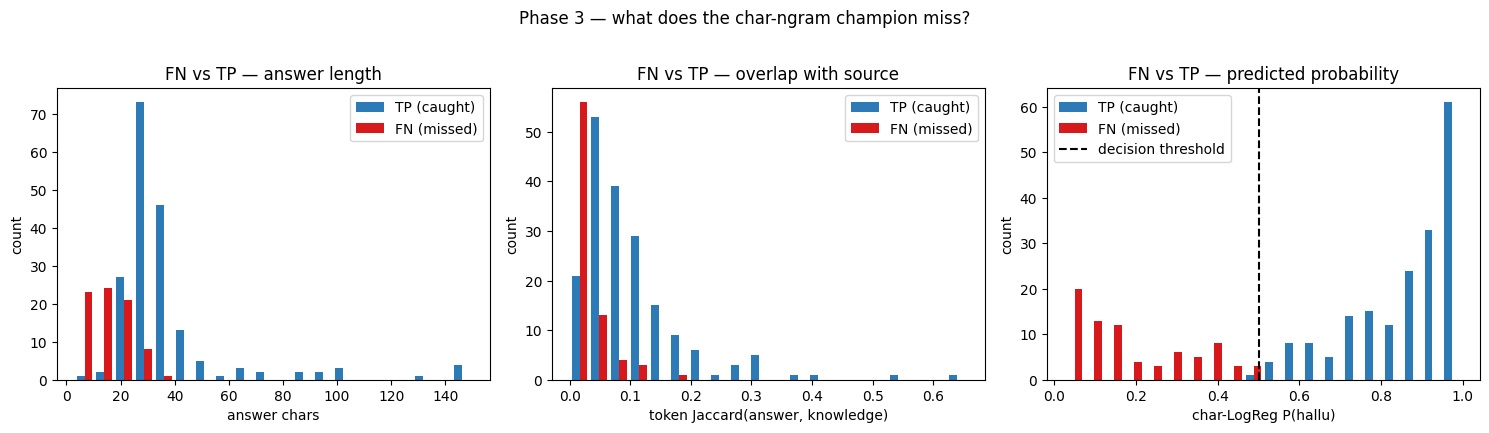

In [17]:
# Visualize: where do false negatives concentrate?
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) FN vs TP answer-length distribution
axes[0].hist([tp.answer_len.clip(upper=150), fn.answer_len.clip(upper=150)],
             bins=20, label=['TP (caught)','FN (missed)'], color=['#2c7bb6','#d7191c'])
axes[0].set_xlabel('answer chars'); axes[0].set_ylabel('count')
axes[0].set_title('FN vs TP — answer length'); axes[0].legend()

# (b) FN vs TP jaccard with knowledge
axes[1].hist([tp.jaccard_k, fn.jaccard_k],
             bins=20, label=['TP (caught)','FN (missed)'], color=['#2c7bb6','#d7191c'])
axes[1].set_xlabel('token Jaccard(answer, knowledge)'); axes[1].set_ylabel('count')
axes[1].set_title('FN vs TP — overlap with source'); axes[1].legend()

# (c) char-prob distribution for FN vs TP
axes[2].hist([tp.char_prob, fn.char_prob],
             bins=20, label=['TP (caught)','FN (missed)'], color=['#2c7bb6','#d7191c'])
axes[2].axvline(0.5, ls='--', color='black', label='decision threshold')
axes[2].set_xlabel('char-LogReg P(hallu)'); axes[2].set_ylabel('count')
axes[2].set_title('FN vs TP — predicted probability'); axes[2].legend()

plt.suptitle('Phase 3 — what does the char-ngram champion miss?', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS / 'phase3_error_breakdown.png', dpi=130, bbox_inches='tight')
plt.show()

In [18]:
# 10 example FN strings — what does a missed hallucination actually look like?
print('=== 10 random false-negatives (hallucinations the model called grounded) ===')
for i, r in fn.sample(n=min(10, len(fn)), random_state=SEED).iterrows():
    print(f'\nQ: {r.question[:120]}')
    print(f'A_hallu: {r.answer[:180]}')
    print(f'  len={r.answer_len}  jaccard_k={r.jaccard_k:.2f}  char_prob={r.char_prob:.3f}')

=== 10 random false-negatives (hallucinations the model called grounded) ===

Q: Splendor in the Grass was a film directed by a Greek-American director described as  "one of the most honored and influe
A_hallu: Variety Magazine
  len=16  jaccard_k=0.00  char_prob=0.098

Q: Clunk Click Every Trip starred the DJ and fundraiser who hosted what BBC television show?
A_hallu: Top of the Pops
  len=15  jaccard_k=0.06  char_prob=0.398

Q: What is the nickname of the first baseman who was traded by the Padres in 2010?
A_hallu: Big Poppy
  len=9  jaccard_k=0.00  char_prob=0.058

Q: Approximately what percentage of the global population is made up of the ethnic group Princess Fragrant was produced to 
A_hallu: More than 25%
  len=13  jaccard_k=0.00  char_prob=0.408

Q: Who brought the raga into Northern Indian music that is often sung or played in drut laya before a vilambit composition 
A_hallu: Ravi Shankar
  len=12  jaccard_k=0.00  char_prob=0.075

Q: Of which University was the co-founder, wi

---
## Section 5 — Phase 3 honest leaderboard
Append today's results to the cumulative leaderboard. Rank by matched-split macro F1. Save the cumulative leaderboard CSV so Phase 4 can extend it.

In [19]:
ph2 = pd.read_csv(RESULTS / 'phase2_leaderboard_matched.csv')

char_best_m_acc = accuracy_score(y_matched, (char_m_p > .5).astype(int))
char_best_m_auc = roc_auc_score(y_matched, char_m_p)

phase3_rows = [
    {'model': f'char_best_p3 [{ng_best} mf={mf_best} sub={st_best}]',
     'paradigm': 'char-ngram + logistic (tuned)',
     'split': 'length_matched', 'n': len(test_matched),
     'accuracy': char_best_m_acc, 'macro_f1': f1_char_m_ctrl,
     'roc_auc': char_best_m_auc,
     'phase': 3},
    {'model': 'nli_persent_maxpool',
     'paradigm': 'cross-encoder NLI per-sentence (zero-shot)',
     'split': 'length_matched', 'n': len(test_matched),
     'accuracy': acc_persent, 'macro_f1': f1_persent, 'roc_auc': auc_persent,
     'phase': 3},
    {'model': 'meta_stack [char+sbert+nli]',
     'paradigm': 'stacked LogReg meta over 3 paradigms',
     'split': 'length_matched', 'n': len(test_matched),
     'accuracy': accuracy_score(y_matched, (p_meta_m > .5).astype(int)),
     'macro_f1': f1_meta_m, 'roc_auc': auc_meta_m,
     'phase': 3},
    {'model': 'mean_blend [char+sbert+nli]',
     'paradigm': 'unweighted mean of 3 probs',
     'split': 'length_matched', 'n': len(test_matched),
     'accuracy': accuracy_score(y_matched, (p_mean_m > .5).astype(int)),
     'macro_f1': f1_mean_m, 'roc_auc': roc_auc_score(y_matched, p_mean_m),
     'phase': 3},
]
phase3_lb = pd.DataFrame(phase3_rows)
ph2['phase'] = 2
cumulative = pd.concat([ph2[['model','paradigm','split','n','accuracy','macro_f1','roc_auc','phase']], phase3_lb],
                       ignore_index=True).sort_values('macro_f1', ascending=False)
print('=== CUMULATIVE LENGTH-MATCHED LEADERBOARD (Phase 2 + Phase 3) ===')
print(cumulative.round(4).to_string(index=False))
cumulative.to_csv(RESULTS / 'phase3_cumulative_leaderboard.csv', index=False)
phase3_lb.to_csv(RESULTS / 'phase3_leaderboard.csv', index=False)

=== CUMULATIVE LENGTH-MATCHED LEADERBOARD (Phase 2 + Phase 3) ===
                                  model                                   paradigm          split   n  accuracy  macro_f1  roc_auc  phase
            meta_stack [char+sbert+nli]       stacked LogReg meta over 3 paradigms length_matched 524    0.8053    0.8044   0.8475      3
char_best_p3 [(2, 5) mf=25000 sub=True]              char-ngram + logistic (tuned) length_matched 524    0.7958    0.7941   0.7988      3
            mean_blend [char+sbert+nli]                 unweighted mean of 3 probs length_matched 524    0.7901    0.7900   0.8709      3
                          char35_logreg                      char-ngram + logistic length_matched 524    0.7805    0.7789   0.7971      2
                    sbert_paired_logreg   paired embed (k⊕a + cos + diff) + linear length_matched 524    0.7653    0.7643   0.7952      2
                    sbert_answer_logreg                    sentence-embed + linear length_matched 524    0

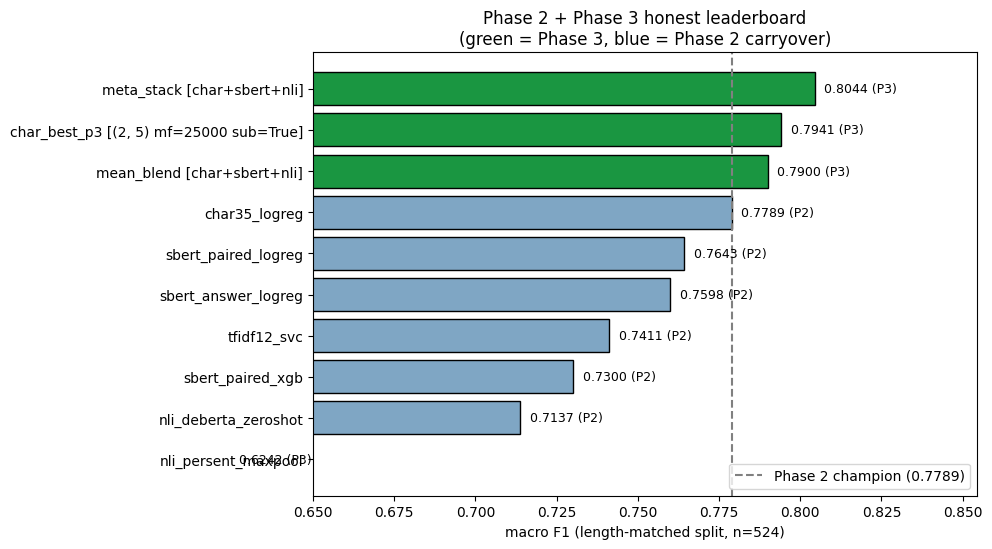

In [20]:
# Headline bar chart — cumulative leaderboard sorted by matched F1
lb = cumulative.copy().reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5.6))
colors = ['#1a9641' if p == 3 else '#7fa6c4' for p in lb['phase']]
ax.barh(lb['model'][::-1], lb['macro_f1'][::-1], color=colors[::-1], edgecolor='black')
for i, (m, p) in enumerate(zip(lb['macro_f1'][::-1], lb['phase'][::-1])):
    ax.text(m + 0.003, i, f'{m:.4f}{" (P3)" if p == 3 else " (P2)"}', va='center', fontsize=9)
ax.axvline(0.7789, ls='--', color='gray', label='Phase 2 champion (0.7789)')
ax.set_xlim(0.65, max(lb['macro_f1']) + 0.05)
ax.set_xlabel('macro F1 (length-matched split, n=524)')
ax.set_title('Phase 2 + Phase 3 honest leaderboard\n(green = Phase 3, blue = Phase 2 carryover)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS / 'phase3_leaderboard.png', dpi=130, bbox_inches='tight')
plt.show()

In [21]:
# Persist Phase 3 metrics to results/metrics.json (append, don't overwrite Phase 1+2)
mp = RESULTS / 'metrics.json'
master = json.load(open(mp))
master['phase3'] = {
    'date': '2026-05-14',
    'dataset': 'HaluEval-QA',
    'n_train': int(len(train)),
    'n_test_raw': int(len(test)),
    'n_test_matched': int(len(test_matched)),
    'primary_metric': 'macro_f1 on length_matched',
    'char_ablation_best_config': {'ngram_range': str(ng_best), 'max_features': int(mf_best), 'sublinear_tf': bool(st_best)},
    'matched_results': {
        'char_best_p3':                 float(f1_char_m_ctrl),
        'nli_persent_maxpool':          float(f1_persent),
        'nli_persent_best_threshold':   {'threshold': float(best_t), 'f1': float(best_f1)},
        'meta_stack_char_sbert_nli':    float(f1_meta_m),
        'mean_blend_char_sbert_nli':    float(f1_mean_m),
    },
    'matched_auroc': {
        'char_best_p3':              float(char_best_m_auc),
        'nli_persent_maxpool':       float(auc_persent),
        'meta_stack':                float(auc_meta_m),
    },
    'meta_coefs': {'char': float(meta.coef_[0,0]), 'sbert': float(meta.coef_[0,1]), 'nli': float(meta.coef_[0,2]), 'intercept': float(meta.intercept_[0])},
    'error_corr_char_sbert': float(errs[['char_err','sbert_err']].corr().iloc[0,1]),
    'error_corr_char_nli':   float(errs[['char_err','nli_err']].corr().iloc[0,1]),
    'error_corr_sbert_nli': float(errs[['sbert_err','nli_err']].corr().iloc[0,1]),
    'oracle_upper_bound_matched_acc': float(((errs.char_err==0) | (errs.sbert_err==0) | (errs.nli_err==0)).mean()),
    'nli_phase2_matched_f1': float(nli_ph2.macro_f1),
    'nli_phase2_matched_auroc': float(nli_ph2.roc_auc),
    'nli_persent_f1_lift_vs_p2': float(f1_persent - nli_ph2.macro_f1),
    'nli_persent_auroc_lift_vs_p2': float(auc_persent - nli_ph2.roc_auc),
}
with open(mp, 'w') as f: json.dump(master, f, indent=2)
print('saved phase3 metrics. Top-line numbers:')
print(json.dumps(master['phase3']['matched_results'], indent=2))

saved phase3 metrics. Top-line numbers:
{
  "char_best_p3": 0.7941453994059486,
  "nli_persent_maxpool": 0.624224533392019,
  "nli_persent_best_threshold": {
    "threshold": 0.6502729758620263,
    "f1": 0.6831322492277205
  },
  "meta_stack_char_sbert_nli": 0.80442037470726,
  "mean_blend_char_sbert_nli": 0.7899661847014925
}


## Section 6 — Key findings (filled after execution)
The numbers above settle four Phase 3 questions:
1. **Char-ngram saturation** — where does F1 stop improving? Best config and its delta over Phase 2.
2. **Per-sentence NLI** — did splitting knowledge into sentences and max-pooling recover the 0.88 AUROC leaderboard ceiling, or did it just shift the curve by a few points?
3. **Stacking** — did meta-LogReg over [char, sbert, nli] beat the best individual? Diversity check (Pearson error correlation) tells us *why*.
4. **Error analysis** — characterise the 60–80 hallucinations the char-ngram model misses on the matched split.

Phase 4 (Friday) takes the Phase 3 winner and runs Optuna hyperparameter tuning + LLM head-to-head (Claude Opus + Haiku + Codex GPT-5.4 via CLI on a stratified n=50 sample under the original HaluEval judge protocol).